# SLC inspection data — sanity check & exploration

Salt Lake County Health Department (SLCHD) public inspection data.

**Files:** `data/slc/establishments.csv`, `inspections.csv`, `violations.csv`

**Goal:** Understand schema and distributions before designing fact tables or an ontology. Findings at the end feed `semantic/gen_ontology.json`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 40)

DATA_DIR = Path("../../data/slc")  # relative to this notebook

for name in ("establishments", "inspections", "violations"):
    path = DATA_DIR / f"{name}.csv"
    if not path.exists():
        raise FileNotFoundError(path.resolve())

est = pd.read_csv(DATA_DIR / "establishments.csv")
insp = pd.read_csv(DATA_DIR / "inspections.csv")
viol = pd.read_csv(DATA_DIR / "violations.csv")

print("Loaded:")
print(f"  establishments: {len(est):>5} rows")
print(f"  inspections:    {len(insp):>5} rows")
print(f"  violations:     {len(viol):>5} rows")

Loaded:
  establishments:   204 rows
  inspections:     1258 rows
  violations:      5515 rows


## 1. Schema overview

Row counts and column inventory for the three tables.

In [2]:
for df_name, df in [("establishments", est), ("inspections", insp), ("violations", viol)]:
    print(f"{df_name}: {len(df)} rows × {len(df.columns)} cols")
    print("  columns:", list(df.columns))
    print()

establishments: 204 rows × 10 cols
  columns: ['establishment_key', 'name', 'address', 'city', 'city_state_zip', 'phone', 'establishment_type', 'rank', 'list_page', 'scraped_at']

inspections: 1258 rows × 8 cols
  columns: ['establishment_key', 'name', 'inspection_date', 'inspection_type', 'score', 'critical_violations', 'noncritical_violations', 'scraped_at']

violations: 5515 rows × 11 cols
  columns: ['establishment_key', 'name', 'inspection_date', 'code', 'observed_violation', 'points', 'critical', 'occurrences', 'cos', 'phr', 'scraped_at']



## 2. Establishments

Primary key is `establishment_key` = `name|address|city` (uppercased). This is **not** a stable government ID — sibling locations with different addresses are separate keys.

In [3]:
print("Columns:", list(est.columns))
print("\nNull counts:\n", est.isnull().sum())
print("\nDuplicate establishment_key:", est["establishment_key"].duplicated().sum())

est["rank_pct"] = est["rank"].str.rstrip("%").astype(float)

display(est.head(3))
display(est[["establishment_type", "rank_pct", "city"]].describe(include="all"))

Columns: ['establishment_key', 'name', 'address', 'city', 'city_state_zip', 'phone', 'establishment_type', 'rank', 'list_page', 'scraped_at']

Null counts:
 establishment_key     0
name                  0
address               0
city                  0
city_state_zip        0
phone                 2
establishment_type    0
rank                  0
list_page             0
scraped_at            0
dtype: int64

Duplicate establishment_key: 0


,establishment_key,name,address,city,city_state_zip,phone,establishment_type,rank,list_page,scraped_at,rank_pct
0,100 LIONS BAR|9256 S STATE ST|SANDY,100 LIONS BAR,9256 S STATE ST,SANDY,"SANDY, UT 84070",(801) 727-2740,Mobiles: Food Carts,89%,1,2026-07-15T04:49:36.216844+00:00,89.0
1,1800 CONTACTS|261 W DATA DR|DRAPER,1800 CONTACTS,261 W DATA DR,DRAPER,"DRAPER, UT 84020",(801) 316-5440,Restaurants: plated,78%,1,2026-07-15T04:50:21.710433+00:00,78.0
2,23 N 900 W SLC|23 N 900 W|SALT LAKE CITY,23 N 900 W SLC,23 N 900 W,SALT LAKE CITY,"SALT LAKE CITY, UT 84116",(785) 218-1510,Commissary,100%,1,2026-07-15T04:51:48.060615+00:00,100.0


,establishment_type,rank_pct,city
count,204,204.000000,204
unique,11,NaN,21
top,Restaurants: non-plated,NaN,SALT LAKE CITY
freq,109,NaN,81
mean,NaN,88.284314,NaN
std,NaN,8.062413,NaN
min,NaN,75.000000,NaN
25%,NaN,81.000000,NaN
50%,NaN,88.000000,NaN
75%,NaN,96.000000,NaN


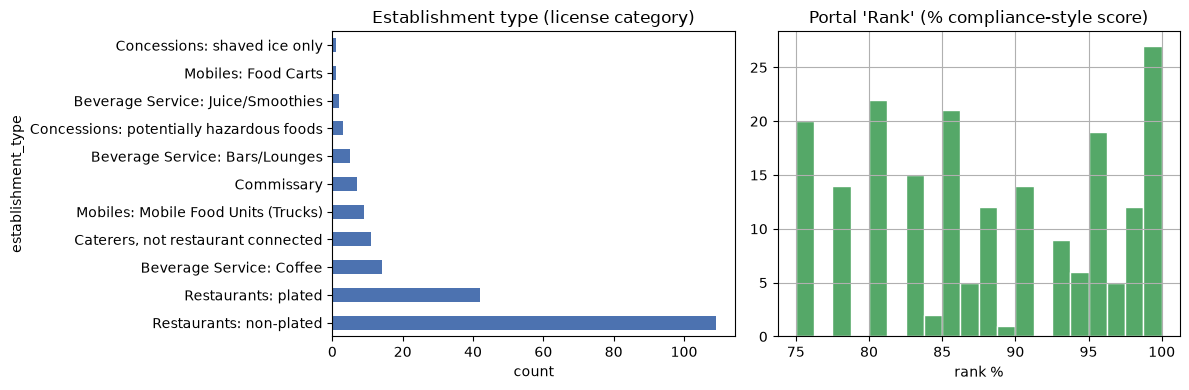

Top cities:
 city
SALT LAKE CITY      81
WEST JORDAN         14
SANDY               13
SOUTH SALT LAKE     11
WEST VALLEY CITY    11
TAYLORSVILLE         9
DRAPER               8
MIDVALE              8
HOLLADAY             7
SOUTH JORDAN         6
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

est["establishment_type"].value_counts().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Establishment type (license category)")
axes[0].set_xlabel("count")

est["rank_pct"].hist(bins=20, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Portal 'Rank' (% compliance-style score)")
axes[1].set_xlabel("rank %")

plt.tight_layout()
plt.show()

print("Top cities:\n", est["city"].value_counts().head(10))

## 3. Inspections

`score` is violation points (lower is better; 0 = clean inspection). `critical_violations` / `noncritical_violations` are summary counts from the portal — often blank when score is 0.

In [5]:
insp["inspection_date"] = pd.to_datetime(insp["inspection_date"], format="mixed")

print("Columns:", list(insp.columns))
print("\nNull counts:\n", insp.isnull().sum())
print("\nInspection types:\n", insp["inspection_type"].value_counts())
print("\nDate range:", insp["inspection_date"].min().date(), "→", insp["inspection_date"].max().date())
print("\nScore describe:\n", insp["score"].describe())
print(f"Score = 0 inspections: {(insp['score'] == 0).sum()} ({100 * (insp['score'] == 0).mean():.1f}%)")

per_est = insp.groupby("establishment_key").size()
print("\nInspections per establishment:\n", per_est.describe())

Columns: ['establishment_key', 'name', 'inspection_date', 'inspection_type', 'score', 'critical_violations', 'noncritical_violations', 'scraped_at']

Null counts:
 establishment_key           0
name                        0
inspection_date             0
inspection_type             0
score                       0
critical_violations       431
noncritical_violations    158
scraped_at                  0
dtype: int64

Inspection types:
 inspection_type
01 - Routine                    1190
02 - Followup                     35
07 - Critical Item                32
03 - Complaint Investigation       1
Name: count, dtype: int64

Date range: 2009-01-09 → 2026-07-14

Score describe:
 count    1258.000000
mean       11.147854
std        11.862863
min         0.000000
25%         3.000000
50%         9.000000
75%        15.000000
max       127.000000
Name: score, dtype: float64
Score = 0 inspections: 89 (7.1%)

Inspections per establishment:
 count    204.000000
mean       6.166667
std        3.653

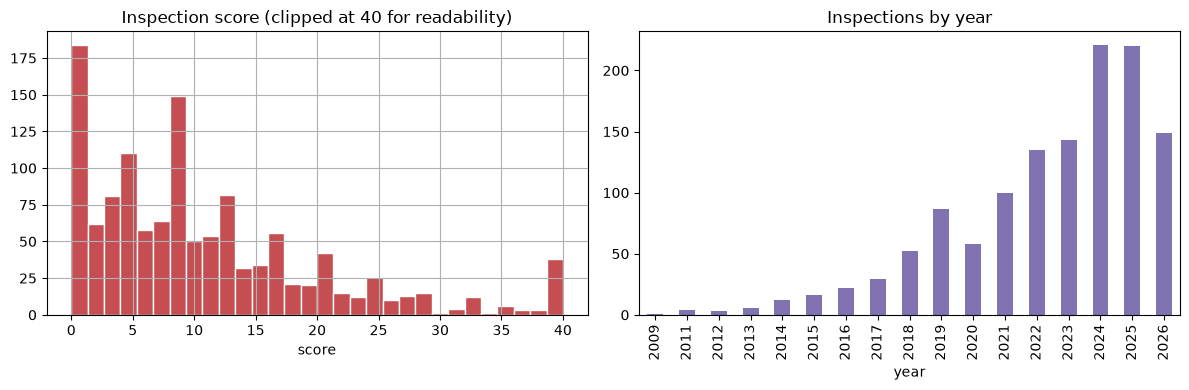

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

insp["score"].clip(upper=40).hist(bins=30, ax=axes[0], color="#C44E52", edgecolor="white")
axes[0].set_title("Inspection score (clipped at 40 for readability)")
axes[0].set_xlabel("score")

insp.groupby(insp["inspection_date"].dt.year).size().plot.bar(ax=axes[1], color="#8172B2")
axes[1].set_title("Inspections by year")
axes[1].set_xlabel("year")

plt.tight_layout()
plt.show()

## 4. Violations

Violations are **structured**: each row has a regulation `code`, free-text `observed_violation`, and a `phr` category label from the Utah Food Code rubric. `critical` is Yes/No. `cos` = corrected on site. `points` is mostly null — prefer `Inspection.score`.

In [7]:
viol["inspection_date"] = pd.to_datetime(viol["inspection_date"], format="mixed")

print("Columns:", list(viol.columns))
print("\nNull counts:\n", viol.isnull().sum())
print("\nCritical flag:\n", viol["critical"].value_counts())
print("\nCorrected on site (cos):\n", viol["cos"].value_counts())
print("\nUnique violation codes:", viol["code"].nunique())
print("Unique phr categories:", viol["phr"].nunique())

viol["code_has_asterisk"] = viol["code"].str.contains(r"\*")
viol["phr_has_asterisk"] = viol["phr"].str.contains(r"\*")

print("\nDoes having an asterisk (*) in the violation code correspond to the 'critical' column being 'Yes'?")
display(pd.crosstab(viol["code_has_asterisk"], viol["critical"], margins=True))

Columns: ['establishment_key', 'name', 'inspection_date', 'code', 'observed_violation', 'points', 'critical', 'occurrences', 'cos', 'phr', 'scraped_at']

Null counts:
 establishment_key        0
name                     0
inspection_date          0
code                     0
observed_violation       0
points                4868
critical                 0
occurrences              0
cos                      0
phr                      0
scraped_at               0
dtype: int64

Critical flag:
 critical
No     3942
Yes    1573
Name: count, dtype: int64

Corrected on site (cos):
 cos
No     5186
Yes     329
Name: count, dtype: int64

Unique violation codes: 165
Unique phr categories: 163

Does having an asterisk (*) in the violation code correspond to the 'critical' column being 'Yes'?


critical,No,Yes,All
code_has_asterisk,,,
False,3941,44,3985
True,1,1529,1530
All,3942,1573,5515


In [8]:
print("Top 20 violation codes:\n")
display(viol["code"].value_counts().head(20).to_frame("count"))

print("\nTop 15 phr (regulation section) categories:\n")
display(viol["phr"].value_counts().head(15).to_frame("count"))

print("\nExample rows for most common code:")
top_code = viol["code"].value_counts().index[0]
display(viol.loc[viol["code"] == top_code, ["code", "phr", "critical", "observed_violation"]].head(3))

Top 20 violation codes:



,count
code,
4.4.85,376
4.6.40,372
4.4.82*,370
4.6.41,351
4.4.63,299
4.5.30,203
4.6.43,176
4.4.61,165
4.3.59*,149



Top 15 phr (regulation section) categories:



,count
phr,
Nonfood-Contact Surfaces-Cleaning,376
Repairing-Physical Facilities,372
"Equipment, Food-Contact Surfaces, Nonfood-Contact Surfaces, and Utensils-Cleaning*",370
Cleaning-Frequency and Restrictions,351
Good Repair and Proper Adjustment,299
System Maintained in Good Repair Non-critical,203
Cleaning Ventilation Systems-Nuisance and Discharge Prohibition,176
Fixed Equipment-Spacing or Sealing,165
"Equipment, Utensils, Linens, and Single-Service and Single-Use Articles-Storage",129



Example rows for most common code:


,code,phr,critical,observed_violation
6,4.4.85,Nonfood-Contact Surfaces-Cleaning,No,Fan covers in the walk-in cooler are dirty.
51,4.4.85,Nonfood-Contact Surfaces-Cleaning,No,Reach-in cooler gaskets are dirty.
64,4.4.85,Nonfood-Contact Surfaces-Cleaning,No,Reach-in cooler handles are dirty.


## 5. Cross-table joins

In [9]:
est_keys = set(est["establishment_key"])
insp_keys = set(insp["establishment_key"])
viol_keys = set(viol["establishment_key"])

print("Establishments with inspections:", len(est_keys & insp_keys), "/", len(est_keys))
print("Establishments with violation rows:", len(est_keys & viol_keys), "/", len(est_keys))
print("Establishments in inspections but not establishments csv:", len(insp_keys - est_keys))
print("Establishments in violations but not establishments csv:", len(viol_keys - est_keys))

no_viol_est = est.loc[~est["establishment_key"].isin(viol_keys), ["name", "establishment_type", "rank"]]
print(f"\nEstablishments with zero violation rows ({len(no_viol_est)}):")
display(no_viol_est.head(15))

# Join inspections ↔ violations on establishment + date
join_cols = ["establishment_key", "inspection_date"]
merged = insp.merge(
    viol.groupby(join_cols).size().rename("violation_row_count").reset_index(),
    on=join_cols,
    how="left",
)
merged["violation_row_count"] = merged["violation_row_count"].fillna(0).astype(int)

print("\nInspections with 0 vs >0 violation detail rows:")
display(merged["violation_row_count"].eq(0).value_counts().rename({True: "no violation rows", False: "has violation rows"}))

# score=0 but no violation rows — expected for clean inspections
clean_no_rows = merged[(merged["score"] == 0) & (merged["violation_row_count"] == 0)]
print(f"score=0 and no violation rows: {len(clean_no_rows)}")

Establishments with inspections: 204 / 204
Establishments with violation rows: 189 / 204
Establishments in inspections but not establishments csv: 0
Establishments in violations but not establishments csv: 0

Establishments with zero violation rows (15):


,name,establishment_type,rank
5,801 COFFEE ROASTERS,Restaurants: plated,100%
16,AN EXQUISITE AFFAIR CATERING@YOSHIS,"Caterers, not restaurant connected",100%
36,ATOMIC BISCUIT - DOG PATIO,Restaurants: non-plated,98%
55,BEAN AROUND #Z047MT,Mobiles: Mobile Food Units (Trucks),98%
72,BLACK SHEEP BAR & GRILL - DOG PATIO,Restaurants: plated,98%
73,BLACK SHEEP BAR AND GRILL FOOTHILL DOG PATIO,Restaurants: plated,98%
86,BRICKYARD COFFEE,Beverage Service: Coffee,100%
105,CAFE RIO,Restaurants: non-plated,83%
115,CAMILLES KITCHEN,"Caterers, not restaurant connected",100%
120,CANYONS EDGE PUB - DOG PATIO,Restaurants: non-plated,98%



Inspections with 0 vs >0 violation detail rows:


violation_row_count
has violation rows    1152
no violation rows      106
Name: count, dtype: int64

score=0 and no violation rows: 87


## 6. Per-establishment inspection trends

Useful for hypothesis types like *improving compliance* vs *declining compliance*.

In [10]:
trend = (
    insp.sort_values("inspection_date")
    .groupby("establishment_key")
    .agg(
        name=("name", "first"),
        n_inspections=("score", "size"),
        first_score=("score", "first"),
        last_score=("score", "last"),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
        last_date=("inspection_date", "max"),
    )
    .assign(score_delta=lambda d: d["last_score"] - d["first_score"])
)

print("Score change (last − first inspection in window):")
display(trend["score_delta"].describe())

print("\nLargest score increases (worsening):")
display(trend.nlargest(8, "score_delta")[["name", "n_inspections", "first_score", "last_score", "score_delta", "last_date"]])

print("\nLargest score decreases (improving):")
display(trend.nsmallest(8, "score_delta")[["name", "n_inspections", "first_score", "last_score", "score_delta", "last_date"]])

Score change (last − first inspection in window):


count    204.000000
mean      -4.666667
std       11.002761
min      -61.000000
25%       -8.000000
50%       -1.000000
75%        0.000000
max       11.000000
Name: score_delta, dtype: float64


Largest score increases (worsening):


,name,n_inspections,first_score,last_score,score_delta,last_date
establishment_key,,,,,,
CARLS JR #207|10475 S STATE ST|SANDY,CARLS JR #207,8,1,12,11,2026-03-24
CARLS JR #241|3469 S REDWOOD RD|WEST VALLEY CITY,CARLS JR #241,9,0,11,11,2026-01-15
CARLS JR #552|8011 W 3500 S|MAGNA,CARLS JR #552,7,2,12,10,2026-01-06
ARBYS #5118|741 E FORT UNION BLVD|MIDVALE,ARBYS #5118,10,1,10,9,2026-01-22
CARLS JR #208|7033 S PLAZA CENTER DR|WEST JORDAN,CARLS JR #208,8,1,10,9,2026-03-12
CARLS JR #93|151 E 5300 S|MURRAY,CARLS JR #93,7,2,11,9,2026-01-28
ARIVO CAFE|4770 S 5600 W|KEARNS,ARIVO CAFE,7,1,9,8,2026-04-30
CARMELLE RECEPTION CENTER|4075 S HIGHLAND DR|HOLLADAY,CARMELLE RECEPTION CENTER,7,1,9,8,2026-04-30



Largest score decreases (improving):


,name,n_inspections,first_score,last_score,score_delta,last_date
establishment_key,,,,,,
ANTOJITOS MEXICANOS EL CABRITO|956 W 1000 N|SALT LAKE CITY,ANTOJITOS MEXICANOS EL CABRITO,10,69,8,-61,2024-12-17
CHARLOTTES|1567 E 3900 S|MILLCREEK TS,CHARLOTTES,10,59,1,-58,2026-01-27
BRIGHTON MOLLY GREEN|12601 E BIG COTTONWOODCYN RD|COTTONWOOD HEIGHTS,BRIGHTON MOLLY GREEN,10,53,2,-51,2026-04-13
COFFEE NOIR|2 N MEDICAL DR|SALT LAKE CITY,COFFEE NOIR,10,53,2,-51,2026-04-13
BASKIN ROBBINS|9497 S 700 E|SANDY,BASKIN ROBBINS,10,50,5,-45,2025-10-30
CAFE ZUPAS|3599 S 2700 W|WEST VALLEY CITY,CAFE ZUPAS,10,53,12,-41,2026-04-29
CHILIS SOUTHWEST GRILL #2|1070 E FORT UNION BLVD|MIDVALE,CHILIS SOUTHWEST GRILL #2,10,35,3,-32,2026-06-02
CAFE RIO MEXICAN GRILL|12362 S MINUTEMAN DR|DRAPER,CAFE RIO MEXICAN GRILL,10,44,13,-31,2026-06-03


## 7. Findings summary (feeds ontology)

Run the cell below for current row counts, then see `semantic/gen_ontology.json`.

In [11]:
findings = [
    (f"{len(est)} establishments", "Fact tables keyed on establishment_key"),
    ("establishment_key is composite, not a gov ID", "Use as join key; defer sibling-group inference"),
    ("establishment_type = SLCHD license category", "Not cuisine; model as EstablishmentType"),
    ("rank is portal % rank (~75–100%)", "Not price tier; model as ComplianceRank"),
    ("No lat/lon, cuisine, menu, owner", "Defer Restaurant enrichment fields"),
    (f"Inspections {insp['inspection_date'].min().date()}–{insp['inspection_date'].max().date()}", "Supports InspectionTrend over available history"),
    ("Violations have code + phr + critical", "Map codes/phr → ViolationType buckets via violation_map.csv"),
    (f"Violation.points null: {viol['points'].isnull().mean():.0%}", "Use Inspection.score + Violation.critical instead"),
    (f"{len(est) - len(viol_keys)} establishments with zero violation rows", "Treat as clean inspection history for those keys"),
    ("No reviews / sentiment / marketing", "Defer ReviewTheme, SentimentTrend, MarketingSignal"),
]

display(pd.DataFrame(findings, columns=["observation", "implication"]))

print("\nNext: hand-curate semantic/violation_map.csv from top code/phr values,")
print("then ETL to DuckDB parquet views aligned with semantic/gen_ontology.json")

,observation,implication
0,204 establishments,Fact tables keyed on establishment_key
1,"establishment_key is composite, not a gov ID",Use as join key; defer sibling-group inference
2,establishment_type = SLCHD license category,Not cuisine; model as EstablishmentType
3,rank is portal % rank (~75–100%),Not price tier; model as ComplianceRank
4,"No lat/lon, cuisine, menu, owner",Defer Restaurant enrichment fields
5,Inspections 2009-01-09–2026-07-14,Supports InspectionTrend over available history
6,Violations have code + phr + critical,Map codes/phr → ViolationType buckets via violation_map.csv
7,Violation.points null: 88%,Use Inspection.score + Violation.critical instead
8,15 establishments with zero violation rows,Treat as clean inspection history for those keys
9,No reviews / sentiment / marketing,"Defer ReviewTheme, SentimentTrend, MarketingSignal"



Next: hand-curate semantic/violation_map.csv from top code/phr values,
then ETL to DuckDB parquet views aligned with semantic/gen_ontology.json
